In [1]:
import torch
import ray_tracing_cuda_float_torch as rt
from algorithms import Algorithms
import matplotlib.pyplot as plt
import time
from skimage.metrics import peak_signal_noise_ratio as psnr


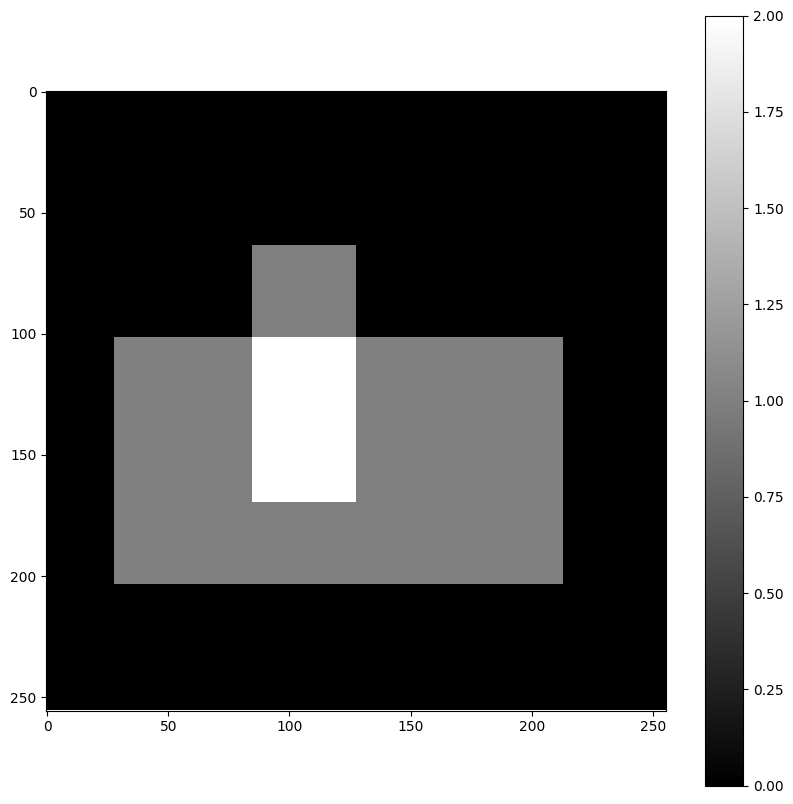

In [2]:
n = 256
img = torch.zeros( ( n, n ), device = 'cuda' )
img[ int( n / 4 ) : int( n / 1.5 ), int( n / 3 ) : int( n / 2 ) ] += 1.0
img[ int( n / 2.5 ) : int( n / 1.25 ), int( n / 9 ) : int( n / 1.2 ) ] += 1.0

plt.figure( figsize = ( 10, 10 ) )
plt.imshow( img.cpu(), cmap = 'gray', interpolation = 'nearest' )
plt.colorbar()
plt.show()

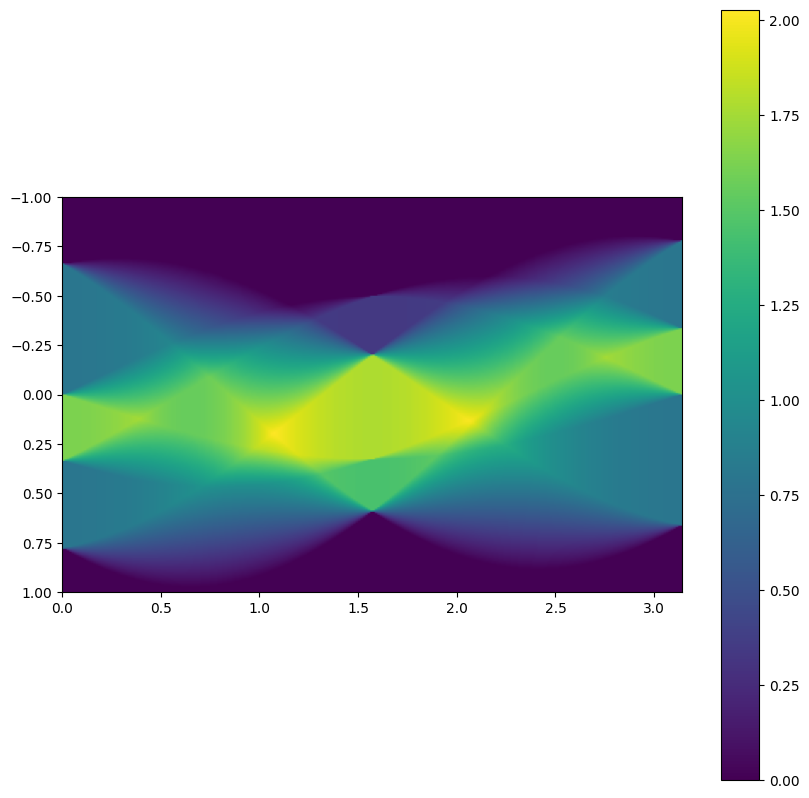

In [3]:
( radon, radon_transpose ) = rt.make_radon_transp(
    ( n, n ),
    sino_top_left = ( 0.0, 1.0 ),
    sino_bottom_right = ( torch.pi, -1.0 ),
    img_shape = ( n, n )    
)

b = radon( img ).clone().detach()
# b = b + 1e-2 * torch.randn_like( b, device = 'cuda' )

plt.figure( figsize = ( 10, 10 ) )
plt.imshow( b.cpu(), extent = ( 0.0, torch.pi, 1.0, -1.0 ) )
plt.colorbar()
plt.show()

In [4]:
def Q( x ):
    return radon_transpose( radon( x ) )

def f( x ):
    return 1/2 * ( ( radon( x ) - b ) ** 2 ).sum()

def grad_f( x ):
    return radon_transpose( radon( x ) - b )

In [5]:
def spectral_norm( Q, shape, device = 'cuda', n_iter = 50, tol = 1e-6):#método das potências
    v = torch.randn( shape, device = device )
    v = v / torch.norm( v )
    
    lambda_old = 0.0
    
    for i in range( n_iter ):
        # 2. Aplica o operador Q(x) = A'A x
        w = Q( v )
        
        # 3. Calcula o autovalor (Norma de Rayleigh)
        # Como v é unitário, lambda = v' * w
        lambda_max = torch.sum( v * w ).item()
        
        # 4. Normaliza para a próxima iteração
        v = w / torch.norm(w)
        
        # Verificação de convergência
        if abs( lambda_max - lambda_old ) < tol:
            break
        lambda_old = lambda_max
            
    return lambda_max

L = spectral_norm( Q, ( n, n ) )
print( f"Norma Espectral (L): {L}" )
print( f"Passo máximo (1/L): {1/L}" )

Norma Espectral (L): 3.8139166831970215
Passo máximo (1/L): 0.2621976521945803


In [6]:
#vamos fazer um teste rápido do algoritmo aqui
x0 = torch.zeros( n, n, device = 'cuda' )
iters = Algorithms.conjugate( Q = Q, b = radon_transpose( b ), x0 = x0, f = f, tol = 0.0001, max_iter = 1000 )

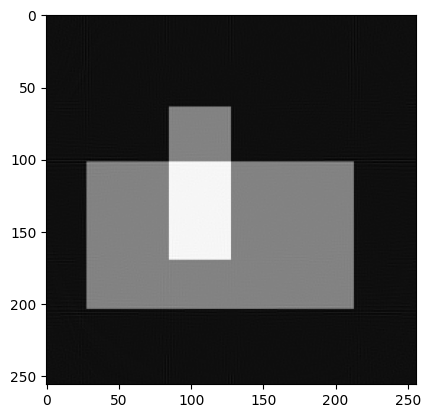

In [7]:
plt.imshow( iters[ -1 ].cpu(), cmap = 'gray' )

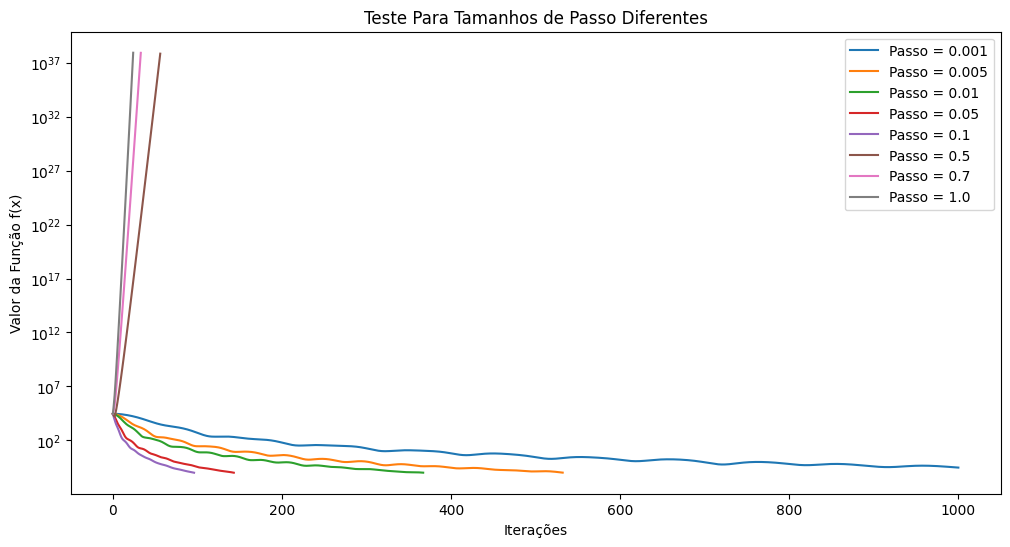

In [8]:
steps = [ 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.7, 1.0 ]
x = torch.zeros_like( img, device = 'cuda' )

lista = []
for step in steps:
    iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = step, tol = 1.0e-1 )
    lista.append( iters_nesterov_fixo )

plt.figure( figsize = ( 12, 6 ) )
for i, step in zip( lista, steps ):
    f_vals_nesterov_fixo = [ f( x ).item() for x in i ]
    plt.semilogy( f_vals_nesterov_fixo, label = f'Passo = {step}' )
plt.title( 'Teste Para Tamanhos de Passo Diferentes' )
plt.xlabel( 'Iterações' )
plt.ylabel( 'Valor da Função f(x)' )
plt.legend()
plt.show()


In [9]:
def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000 ):
    results = {}
    for name, method in methods.items():
        print( f"Executando método: {name}" )
        start_time = time.perf_counter()
        iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
        end_time = time.perf_counter()

        exec_time = end_time - start_time
        values = [ f( x ).item() for x in iters ]

        results[ name ] = {
            "iterations": len( iters ),
            "execution_time": exec_time,
            "function_values": values,
            "iters" : iters
        }
        print( f"{name}: {len( iters )} iterações, {exec_time:.4f} segundos." )
    return results

# Começando alguns experimentos

In [10]:
x0 = torch.zeros_like( img )
tol = 1e-2
max_iter = 999


In [11]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = Q, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 0.1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 0.1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( Q, radon_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 346 iterações, 3.3152 segundos.
Executando método: MDPF
MDPF: 1000 iterações, 5.6012 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 178 iterações, 0.9974 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 85 iterações, 0.6063 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 31 iterações, 0.1832 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 178 iterações, 1.5680 segundos.


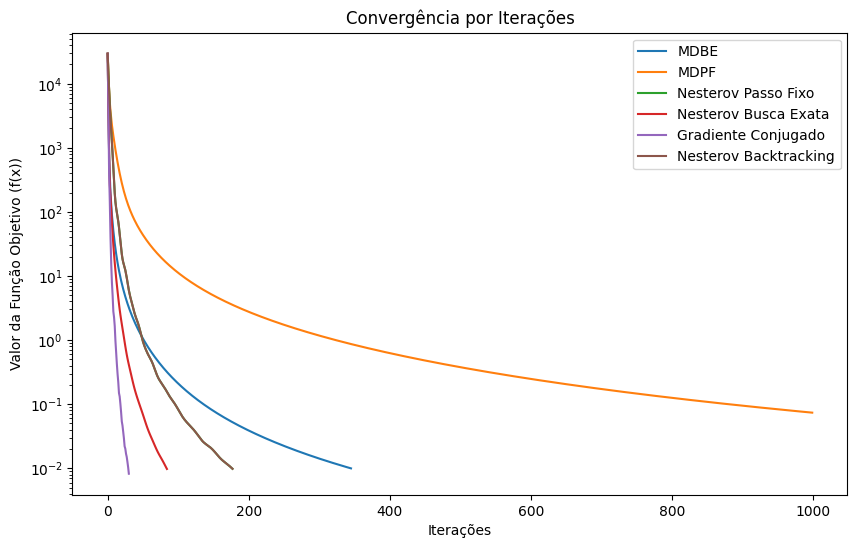

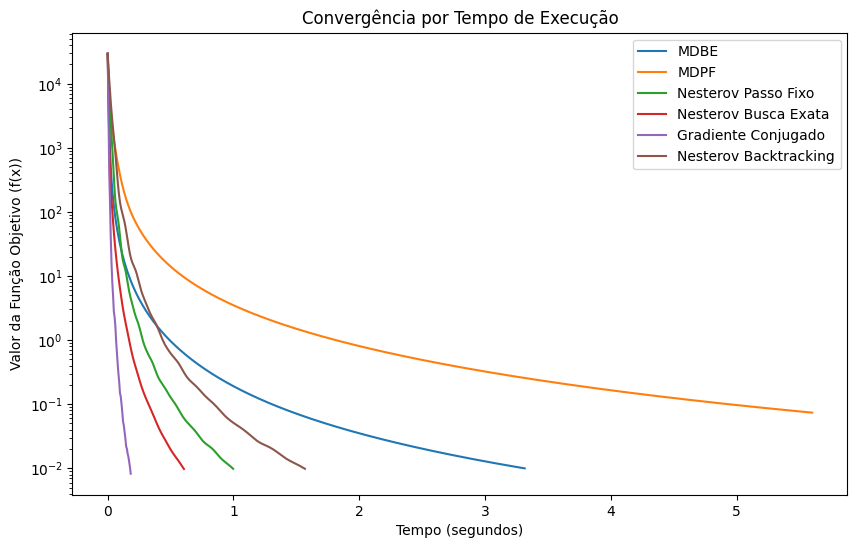

In [12]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


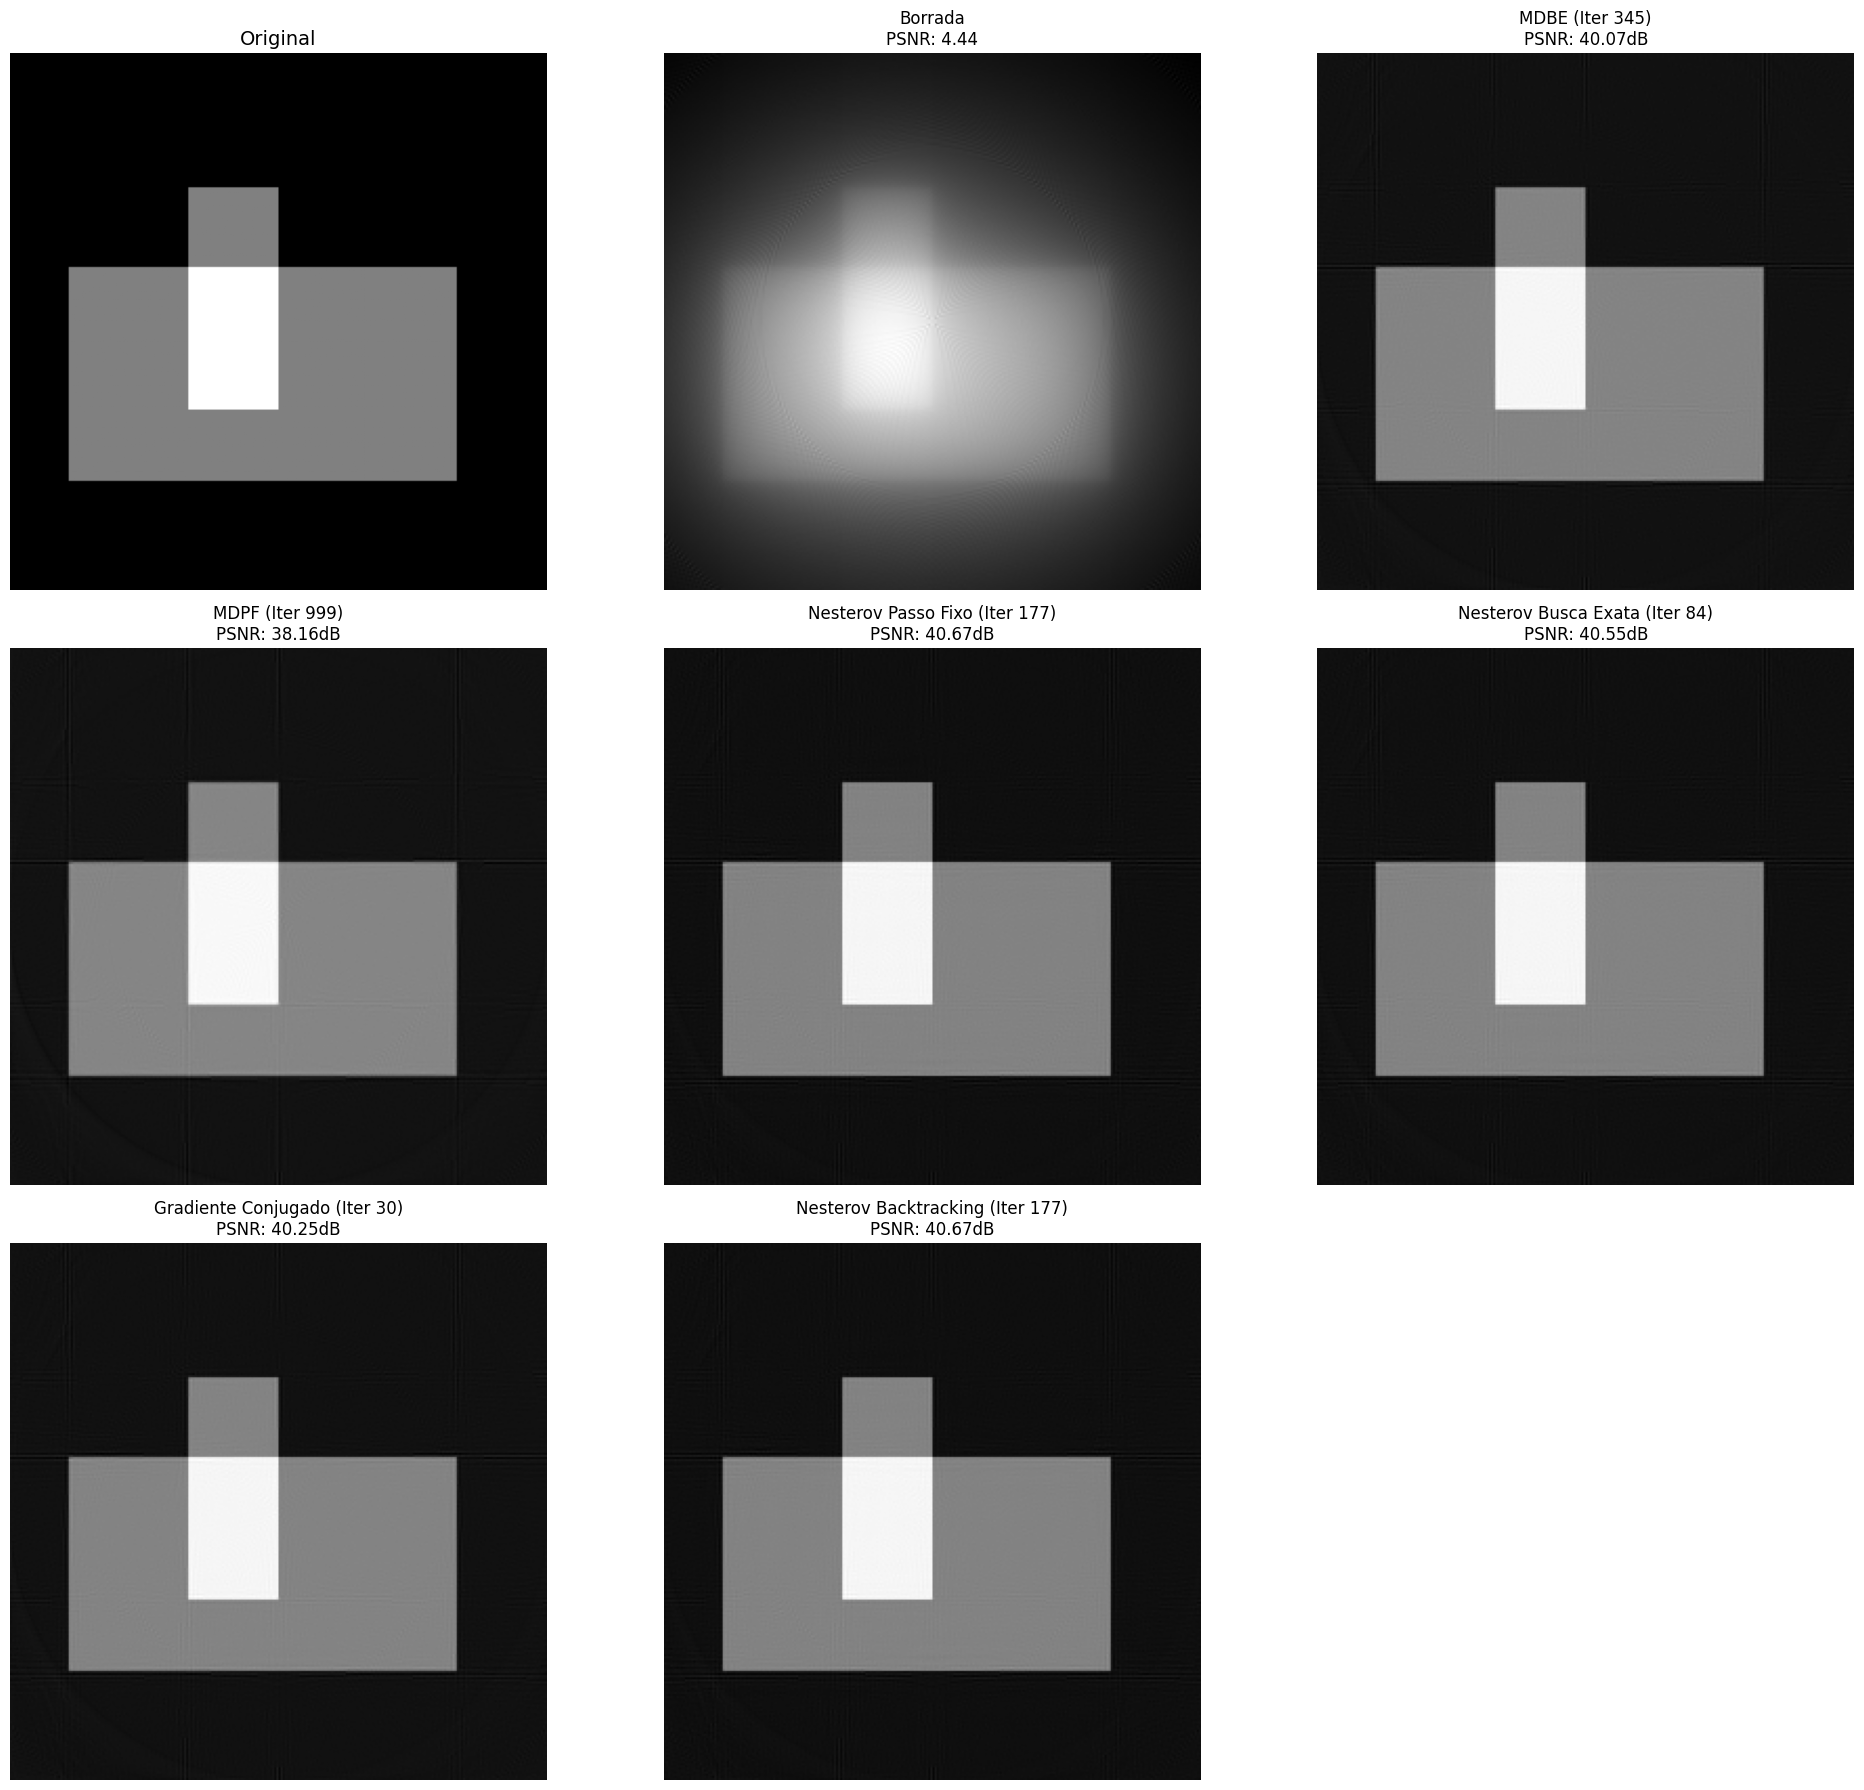

In [21]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Agora por iterações


In [23]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 199


In [24]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, Q = Q, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 0.1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 0.1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( Q, radon_transpose( b ), x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: MDBE
MDBE: 200 iterações, 1.9860 segundos.
Executando método: MDPF
MDPF: 200 iterações, 1.1303 segundos.
Executando método: Nesterov Passo Fixo
Nesterov Passo Fixo: 200 iterações, 1.1450 segundos.
Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 200 iterações, 1.4619 segundos.
Executando método: Gradiente Conjugado
Gradiente Conjugado: 200 iterações, 1.1807 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 200 iterações, 1.7660 segundos.


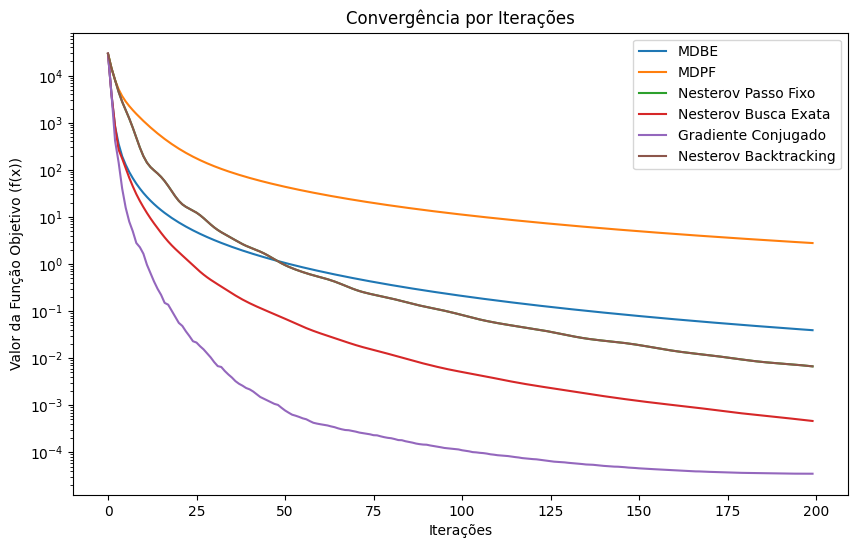

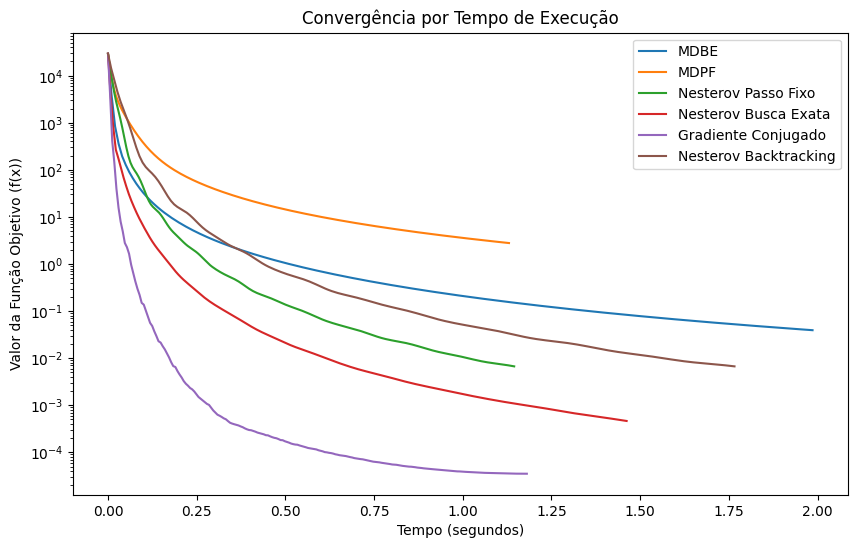

In [25]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


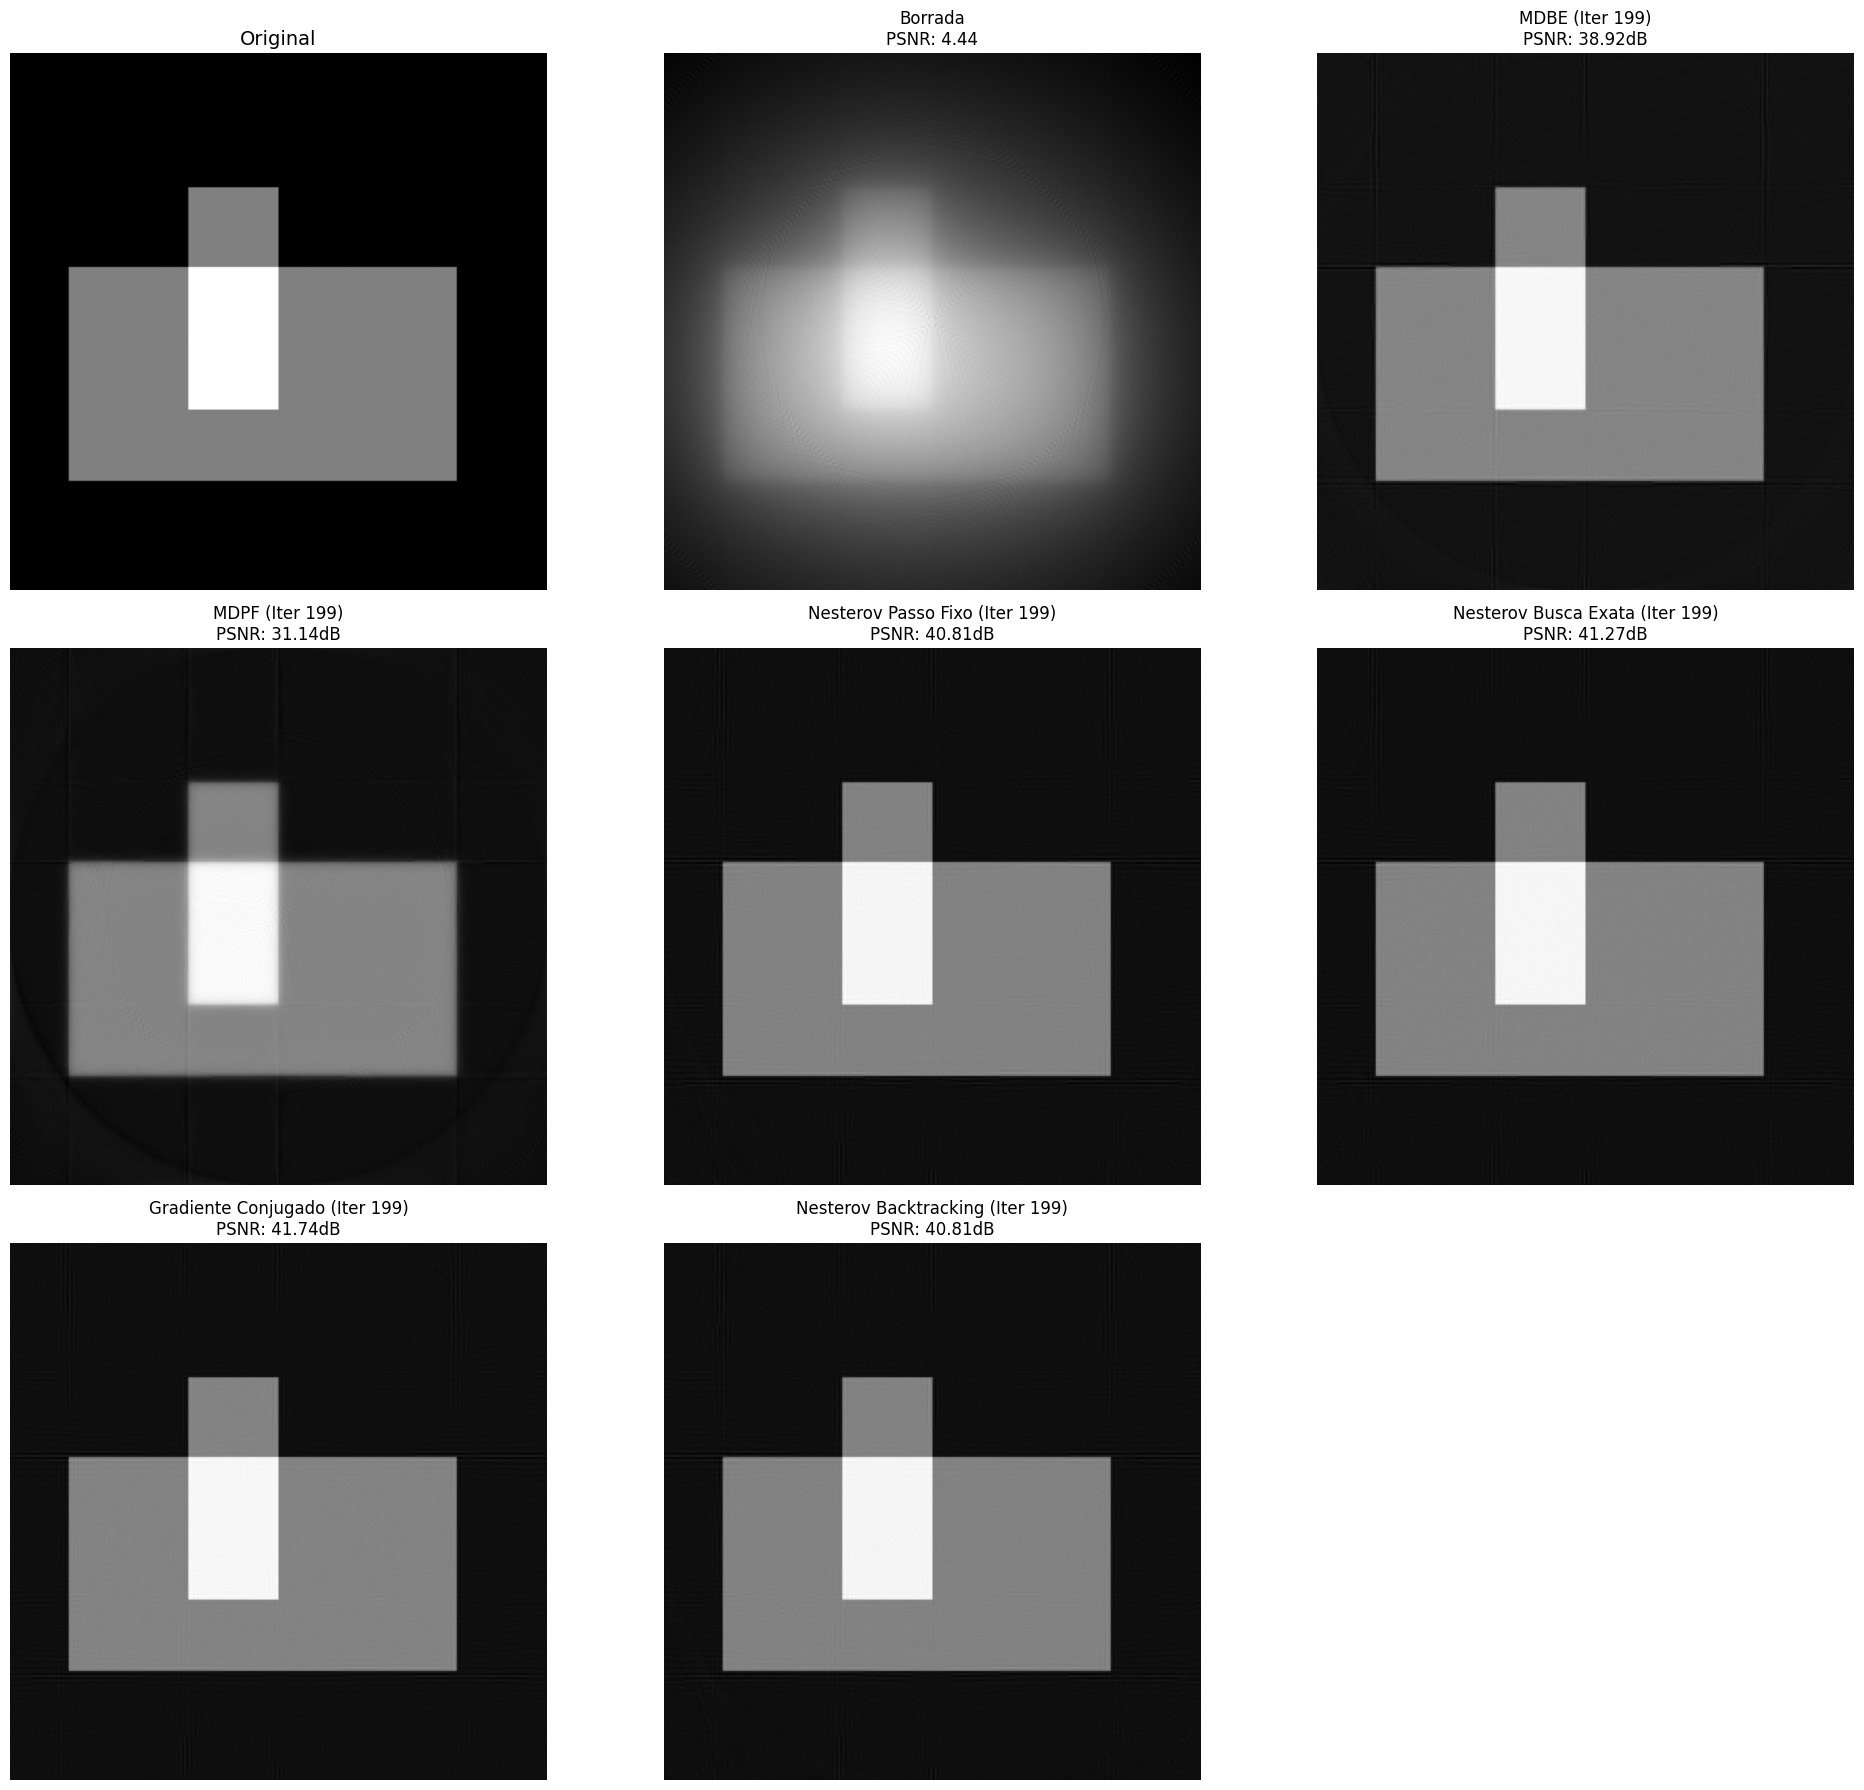

In [26]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Agora explorando melhor o Nesterov com busca exata e com backtracking

In [27]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 199

In [28]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 200 iterações, 1.4868 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 200 iterações, 1.7663 segundos.


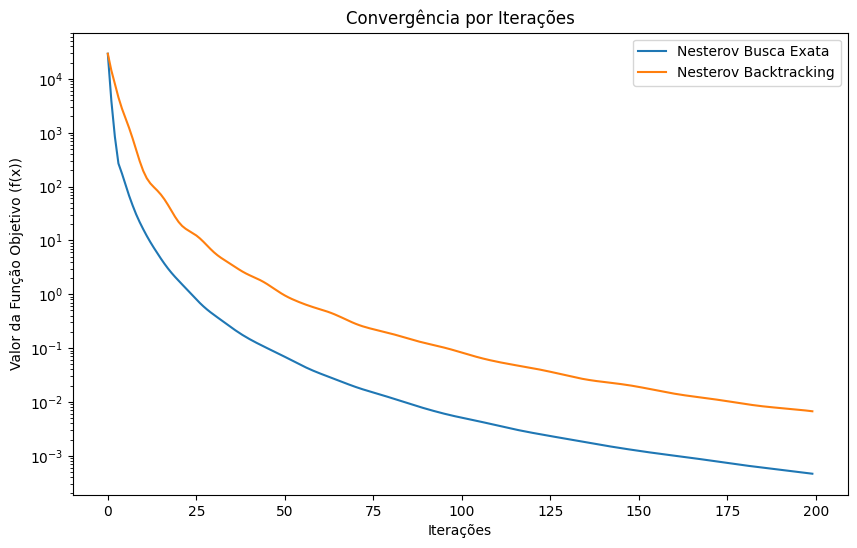

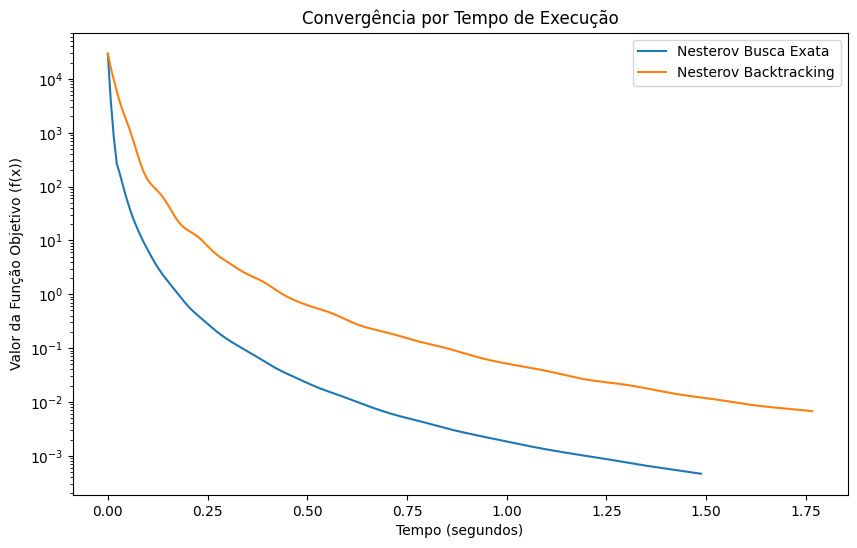

In [29]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


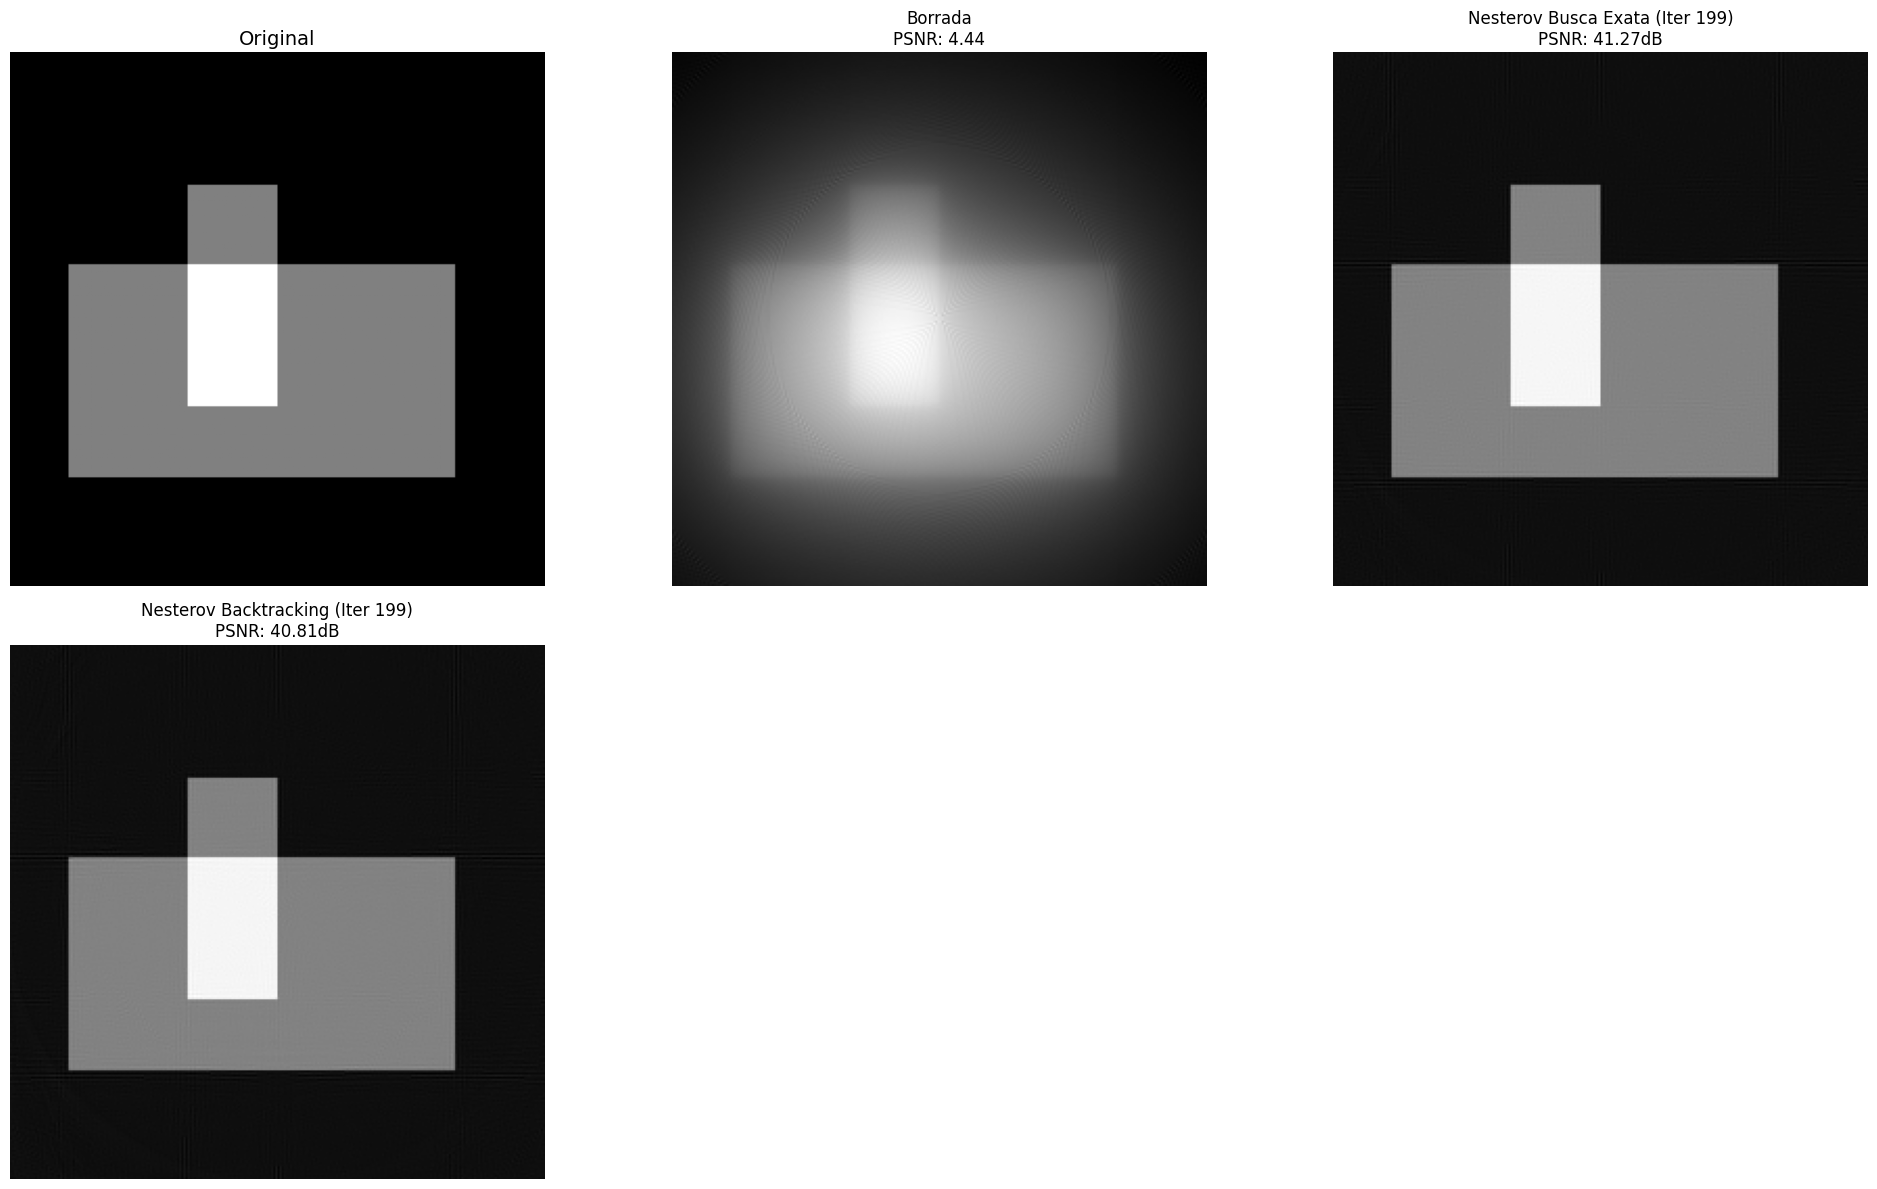

In [31]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

In [32]:
x0 = torch.zeros_like( img )
tol = 1e-2
max_iter = 499

In [33]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Executando método: Nesterov Busca Exata
Nesterov Busca Exata: 85 iterações, 0.6495 segundos.
Executando método: Nesterov Backtracking
Nesterov Backtracking: 178 iterações, 1.5565 segundos.


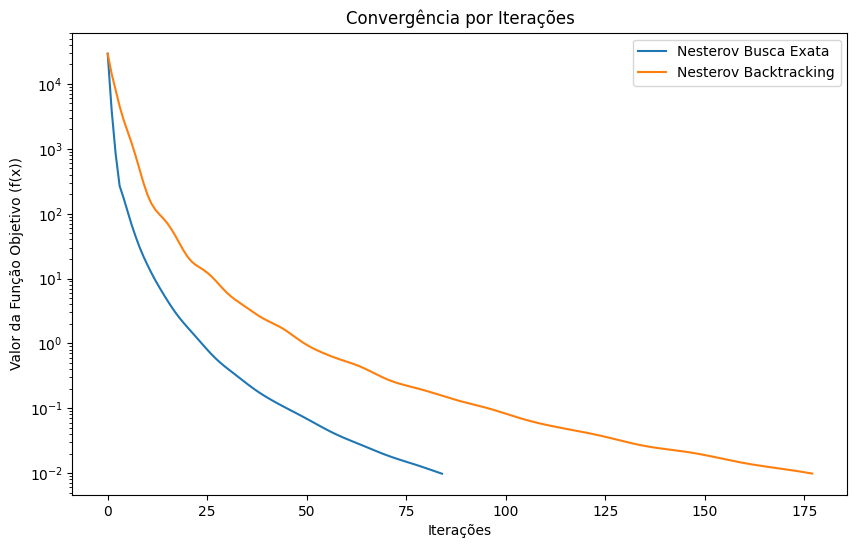

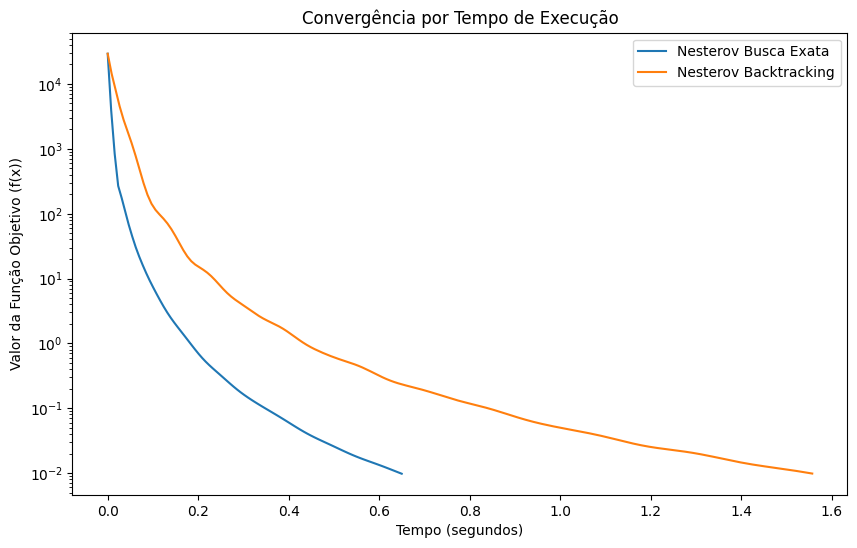

In [34]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "execution_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


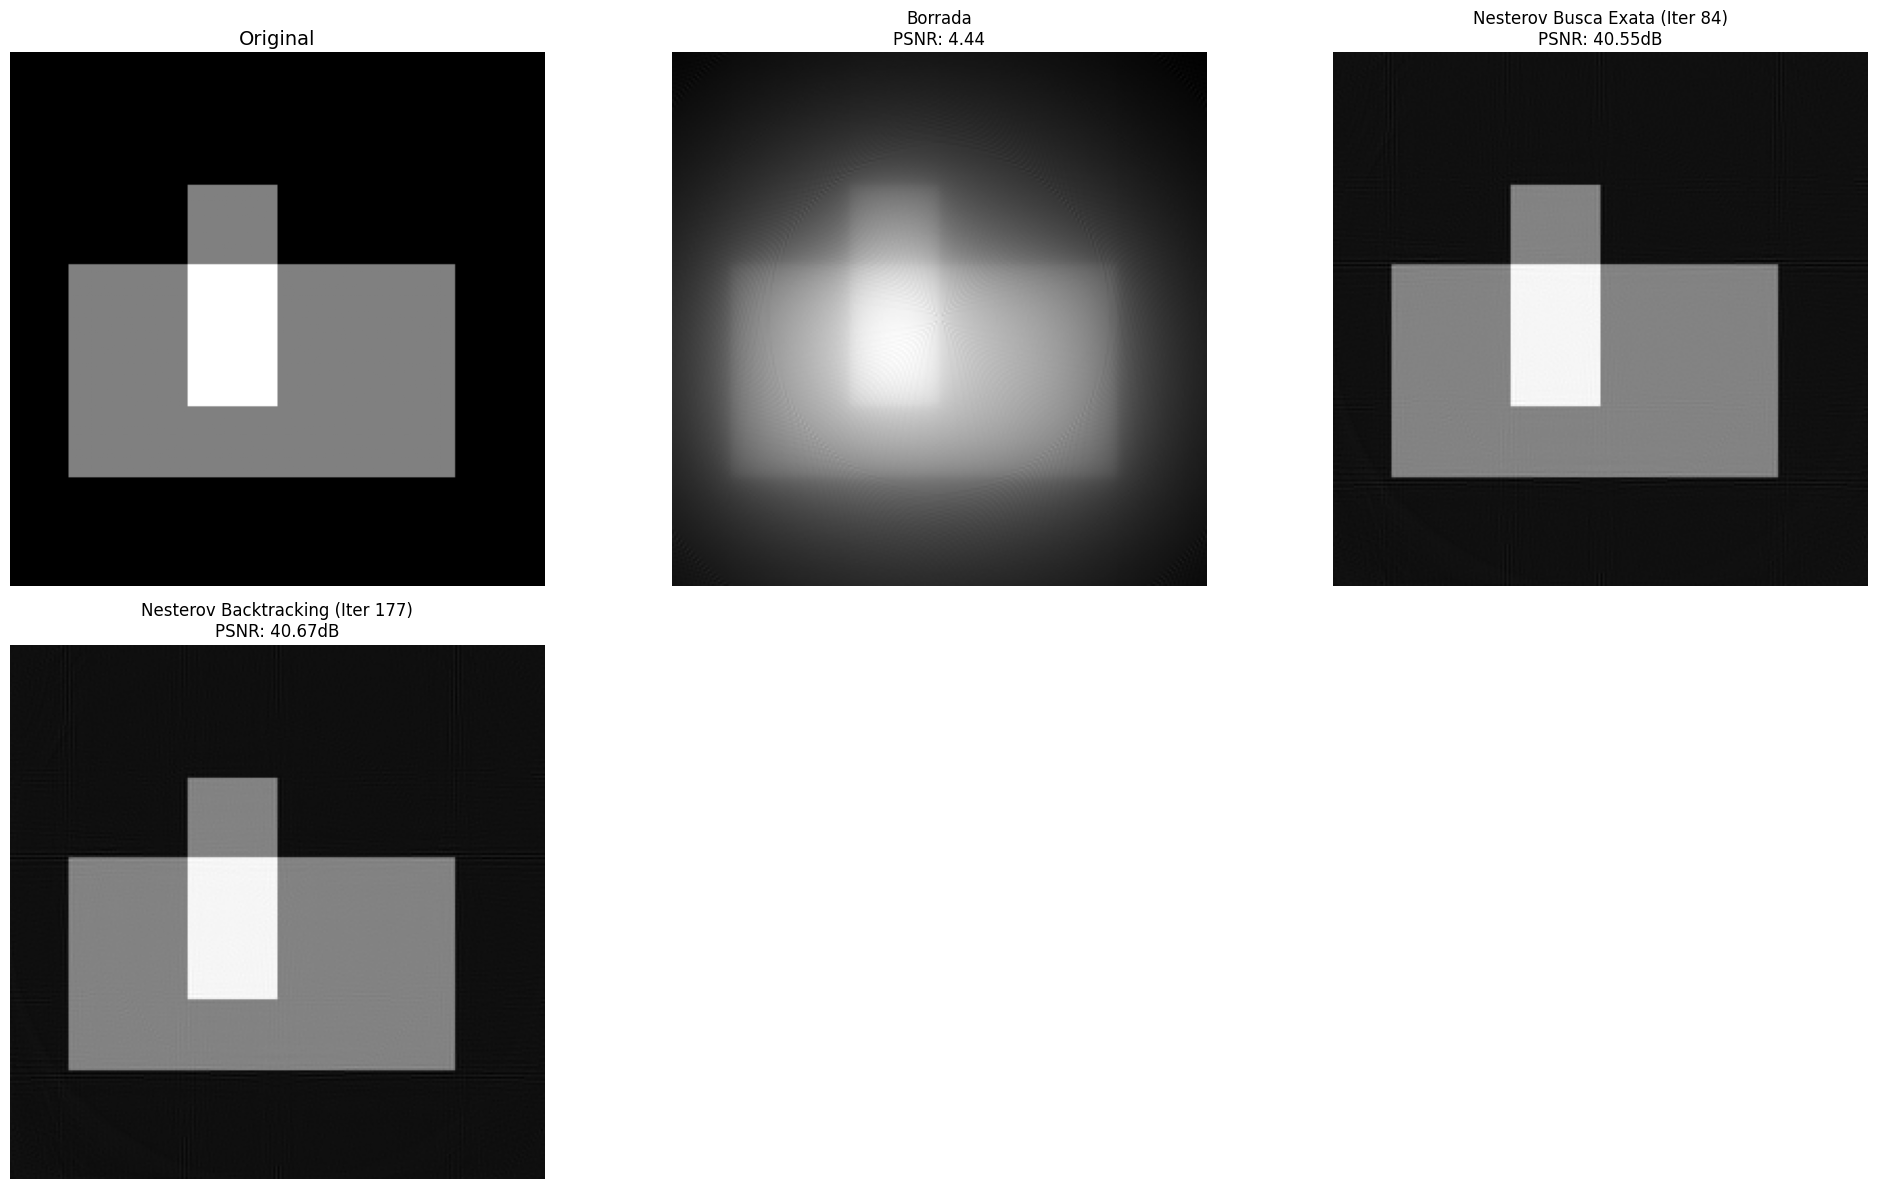

In [35]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()